In [96]:
import pandas as pd
import re
from rapidfuzz import process, fuzz

In [97]:
df = pd.read_csv("C:/SAG/User_Domain_Analysis/business_domain_lead_deal/deal_data_enriched.csv")
df.head()

,domain,country,category,company_size,email_provider,confidence,other_industry_category,website,website_status,website_reason
0,hrops.co.uk,United Kingdom,Professional Services,1 to 5,No,40,Human Resources Consultancy,unreachable,unreachable,Timeout
1,dudscuapcut.store,United Kingdom,E-commerce and Retail,solo,No,10,NaN,unreachable,unreachable,Connection Error
2,gmail.com,United States,Technology and Software Development,500+,Yes,100,NaN,little_info,reachable,200
3,prohade.com,United States,Professional Services,1 to 5,No,40,NaN,unreachable,unreachable,Connection Error
4,dcpa.net,United States,Technology and Software Development,solo,Yes,95,NaN,much_info,reachable,200


In [98]:
# Clean text for comparison
def normalize_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)  # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["other_industry_category"].fillna("").apply(normalize_text)

# Unique clean names
categories = df["clean_text"].unique().tolist()

# Fuzzy grouping
groups = []
used = set()
threshold = 70  # slightly more lenient for better merging

for cat in categories:
    if cat in used or not cat:
        continue
    matches = process.extract(cat, categories, scorer=fuzz.token_sort_ratio)
    similar = [m[0] for m in matches if m[1] >= threshold]
    if similar:
        used.update(similar)
        groups.append(similar)

# Map canonical label (shortest original form)
group_label_map = {}
for group in groups:
    # Get the actual original text for each normalized version
    original_texts = df[df["clean_text"].isin(group)]["other_industry_category"].unique().tolist()
    canonical_label = min(original_texts, key=len)  # shortest original as canonical
    for norm_text in group:
        originals = df[df["clean_text"] == norm_text]["other_industry_category"].unique().tolist()
        for item in originals:
            group_label_map[item] = canonical_label

# Apply mapping
df["standard_category"] = df["other_industry_category"].map(group_label_map)
df.loc[df["standard_category"].isna(), "standard_category"] = df["other_industry_category"]

# Save mapping and cleaned file
mapping_df = pd.DataFrame(list(group_label_map.items()), columns=["original_category", "standard_category"])
#mapping_df.to_csv("category_mapping.csv", index=False)
#df.drop(columns="clean_text").to_csv("cleaned_other_category.csv", index=False)

print("✅ Enhanced cleaning complete!")
print(f"👉 {len(group_label_map)} unique categories standardized.")
print("👉 Saved mapping to: category_mapping.csv")
print("👉 Saved cleaned dataset to: cleaned_other_category.csv")

print("\n🧩 Example auto-merged groups:")
for i, g in enumerate(groups, 1):
    originals = df[df["clean_text"].isin(g)]["other_industry_category"].unique().tolist()
    print(f"Group {i}: {originals}")
    print(f" → Canonical label: {min(originals, key=len)}\n")

✅ Enhanced cleaning complete!
👉 362 unique categories standardized.
👉 Saved mapping to: category_mapping.csv
👉 Saved cleaned dataset to: cleaned_other_category.csv

🧩 Example auto-merged groups:
Group 1: ['Human Resources Consultancy']
 → Canonical label: Human Resources Consultancy

Group 2: ['Travel Agency']
 → Canonical label: Travel Agency

Group 3: ['Event Management', 'Entertainment Management', 'Influencer Management']
 → Canonical label: Event Management

Group 4: ['Domain Parking', 'Domain Parking/Sales', 'Domain Parking Service', 'Domain Parking/Sedo', 'Domain Parking/Reseller']
 → Canonical label: Domain Parking

Group 5: ['Personal Blog/Writing', 'Personal Blog', 'Blogging/Personal Website']
 → Canonical label: Personal Blog

Group 6: ['Interior Design', 'Interior Design / Home Decor']
 → Canonical label: Interior Design

Group 7: ['Beauty and Personal Care Services']
 → Canonical label: Beauty and Personal Care Services

Group 8: ['Lead Generation for Legal and Insurance S

In [99]:
df.head(2)

,domain,country,category,company_size,email_provider,confidence,other_industry_category,website,website_status,website_reason,clean_text,standard_category
0,hrops.co.uk,United Kingdom,Professional Services,1 to 5,No,40,Human Resources Consultancy,unreachable,unreachable,Timeout,human resources consultancy,Human Resources Consultancy
1,dudscuapcut.store,United Kingdom,E-commerce and Retail,solo,No,10,NaN,unreachable,unreachable,Connection Error,,NaN


In [100]:
df = df[['domain', 'category', 'standard_category', 'company_size', 'email_provider', 'website', 'confidence']]
df.rename(columns={
    'standard_category': 'other_category'
}, inplace=True)
df.head(2)

,domain,category,other_category,company_size,email_provider,website,confidence
0,hrops.co.uk,Professional Services,Human Resources Consultancy,1 to 5,No,unreachable,40
1,dudscuapcut.store,E-commerce and Retail,NaN,solo,No,unreachable,10


In [101]:
df.to_csv('deal_data_cleaned.csv', index = False)

For Category

In [102]:
category = df['category'].value_counts().reset_index()
category.columns = ['category', 'count']

# Add percentage column
total = category['count'].sum()
category['percentage'] = (category['count'] / total) * 100

category['percentage'] = category['percentage'].round(1)

category

,category,count,percentage
0,Technology and Software Development,1279,29.5
1,Professional Services,982,22.6
2,E-commerce and Retail,424,9.8
3,Other,365,8.4
4,Marketing and Advertising,363,8.4
5,Financial Service,246,5.7
6,Education and e-learning,185,4.3
7,Real Estate and Property Management,139,3.2
8,Manufacturing and Industrial,134,3.1
9,Logistics and Transportation,116,2.7


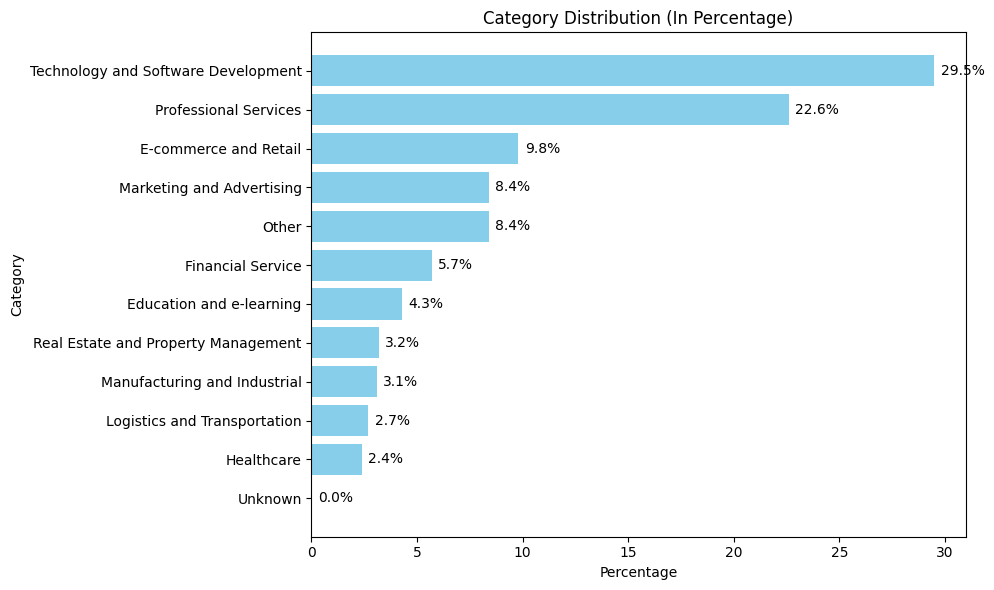

In [103]:
import matplotlib.pyplot as plt

# Sort by percentage ascending (largest on top)
category_sorted = category.sort_values('percentage', ascending=True)

plt.figure(figsize=(10,6))

# Store bars for labeling
bars = plt.barh(category_sorted['category'], category_sorted['percentage'], color='skyblue')

# Add percentage labels right after each bar
for bar, perc in zip(bars, category_sorted['percentage']):
    plt.text(bar.get_width() + 0.3,                # X position just after the bar
             bar.get_y() + bar.get_height()/2,    # Y position: vertical center of the bar
             f'{perc:.1f}%', 
             va='center', fontsize=10)

plt.xlabel("Percentage")
plt.ylabel("Category")
plt.title("Category Distribution (In Percentage)")
plt.tight_layout()
plt.show()



For Company size

In [104]:
size = df['company_size'].value_counts().reset_index()
size.columns = ['company_size', 'count']

# Add percentage column
total = size['count'].sum()
size['percentage'] = (size['count'] / total) * 100

size['percentage'] = size['percentage'].round(1)

size

,company_size,count,percentage
0,1 to 5,1567,36.1
1,5 to 20,935,21.6
2,solo,706,16.3
3,50 to 100,546,12.6
4,20 to 50,343,7.9
5,500+,173,4.0
6,200 to 500,47,1.1
7,100 to 200,20,0.5
8,50+,1,0.0


For Email Provider

In [105]:
email_provider = df['email_provider'].value_counts().reset_index()
email_provider.columns = ['email_provider', 'count']

# Add percentage column
total = size['count'].sum()
email_provider['percentage'] = (email_provider['count'] / total) * 100

email_provider['percentage'] = email_provider['percentage'].round(1)

email_provider

,email_provider,count,percentage
0,No,4268,98.4
1,Yes,69,1.6
2,Unknown,1,0.0


For Confidence

In [106]:
confidence = df['confidence'].value_counts().reset_index()
confidence.columns = ['confidence', 'count']

# Add percentage column
total = confidence['count'].sum()
confidence['percentage'] = (confidence['count'] / total) * 100

confidence['percentage'] = confidence['percentage'].round(1)

confidence

,confidence,count,percentage
0,95,2874,66.3
1,50,309,7.1
2,60,296,6.8
3,75,221,5.1
4,70,157,3.6
5,40,117,2.7
6,100,76,1.8
7,10,75,1.7
8,65,38,0.9
9,80,36,0.8


For Websites

In [107]:
websites = df['website'].value_counts().reset_index()
websites.columns = ['websites', 'count']

# Add percentage column
total = websites['count'].sum()
websites['percentage'] = (websites['count'] / total) * 100

websites['percentage'] = websites['percentage'].round(1)

websites

,websites,count,percentage
0,much_info,2768,63.8
1,unreachable,840,19.4
2,little_info,510,11.8
3,no_info,219,5.0
4,Unknown,1,0.0


For Other

In [108]:
other_category = df['other_category'].value_counts().reset_index()
other_category.columns = ['other_category', 'count']

# Add percentage column
total = other_category['count'].sum()
other_category['percentage'] = (other_category['count'] / total) * 100

other_category['percentage'] = other_category['percentage'].round(1)

other_category

,other_category,count,percentage
0,Travel Agency,47,8.1
1,Non-profit,35,6.0
2,Pet Services,33,5.7
3,Domain Parking,26,4.5
4,Entertainment,23,4.0
...,...,...,...
229,Oil and Gas,1,0.2
230,Financial Advisory and Structuring,1,0.2
231,Retail,1,0.2
232,Mining,1,0.2
